In [9]:
##LOAD AND VALIDATE


In [10]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PRODUCTS_FILE = "MotorPH_Products_Preprocessed.csv"
CATEGORY_COL = "Product Type"


def load_csv(path):
    """Load a CSV file, stopping with a clear message if it is missing or empty."""
    if not Path(path).exists():
        sys.exit(f"ERROR: file not found -> {path} (keep it in the same folder as this script)")
    data = pd.read_csv(path)
    if data.empty:
        sys.exit(f"ERROR: {path} is empty.")
    return data


def validate_categories(data, column):
    """Check the category column exists, drop blank categories and report data quality."""
    if column not in data.columns:
        sys.exit(f"ERROR: column '{column}' not found. Available columns: {list(data.columns)}")
    blank = data[column].isna() | (data[column].astype(str).str.strip() == "")
    clean = data[~blank].copy()
    clean[column] = clean[column].astype(str).str.strip()
    report = {
        "Rows loaded": len(data),
        "Blank categories removed": int(blank.sum()),
        "Duplicate rows": int(clean.duplicated().sum()),
        "Duplicate Product IDs": int(clean["Product ID Number"].duplicated().sum()),
        "Rows used": len(clean),
    }
    return clean, report


products = load_csv(PRODUCTS_FILE)
products, report = validate_categories(products, CATEGORY_COL)

for key, value in report.items():
    print(f"{key}: {value}")
print()
print(products.head().to_string(index=False))

Rows loaded: 50
Blank categories removed: 0
Duplicate rows: 0
Duplicate Product IDs: 0
Rows used: 50

 Product ID Number              Product Name Product Type  Unit Price  Date of Manufacturing  Date of Acquisition
                 1             Honda CBR500R        Sport      389000                   2021                 2023
                 2              Yamaha MT-15   Naked Bike      178000                   2022                 2023
                 3        Kawasaki Ninja 400        Sport      340000                   2023                 2024
                 4     Suzuki Raider R150 Fi    Underbone      119900                   2020                 2021
                 5 Royal Enfield Classic 350      Classic      250000                   2022                 2023


In [11]:
## Step 2: PRODUCT PER CATEGORY



In [12]:
def summarize_categories(data, column):
    """Count products per category and compute each category's share of the total."""
    counts = data[column].value_counts()
    table = pd.DataFrame({
        "Category": counts.index,
        "Product Count": counts.values,
        "Percentage (%)": (counts.values / counts.sum() * 100).round(1),
    })
    # Correctness check: the counts must add up to the number of products
    assert table["Product Count"].sum() == len(data), "Category counts do not match the number of products."
    return table


summary = summarize_categories(products, CATEGORY_COL)
total = int(summary["Product Count"].sum())

print(f"Total products: {total}")
print(f"Number of categories: {len(summary)}\n")
print(summary.to_string(index=False))

Total products: 50
Number of categories: 17

     Category  Product Count  Percentage (%)
      Scooter             12            24.0
   Naked Bike              7            14.0
        Sport              4             8.0
    Adventure              4             8.0
      Cruiser              4             8.0
    Underbone              3             6.0
   Dual-Sport              3             6.0
   Cafe Racer              2             4.0
     Commuter              2             4.0
     Heritage              2             4.0
      Classic              1             2.0
        Retro              1             2.0
Sport Touring              1             2.0
    Scrambler              1             2.0
     Standard              1             2.0
      Touring              1             2.0
       Street              1             2.0


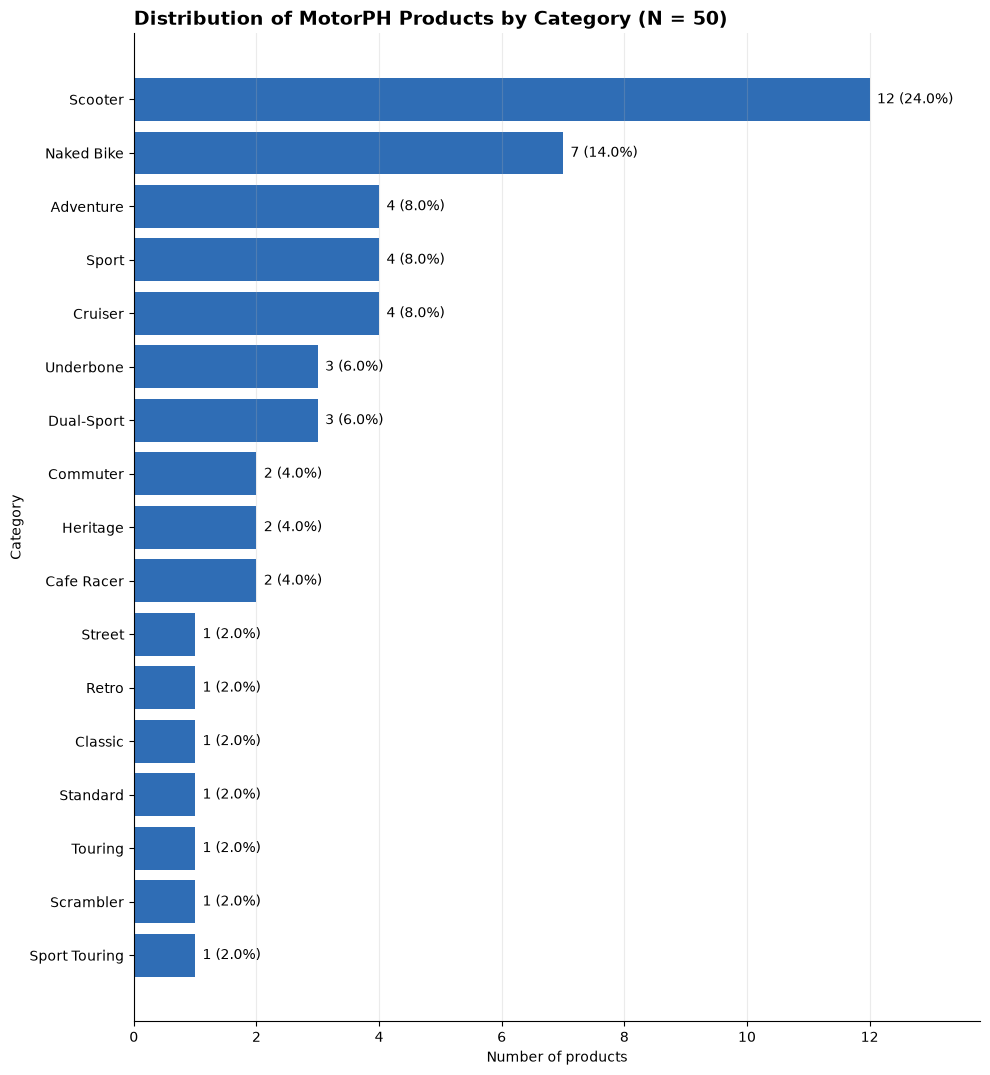

In [13]:
## Step 3: Chart the distribution of products by category

def plot_category_distribution(table, total, out_path):
    """Horizontal bar chart of products per category, sorted largest first and labelled."""
    ordered = table.sort_values("Product Count")  # largest category ends up on top
    fig, ax = plt.subplots(figsize=(10, max(4, 0.55 * len(ordered) + 1.5)))
    bars = ax.barh(ordered["Category"], ordered["Product Count"], color="#2F6DB5")

    for bar, count, pct in zip(bars, ordered["Product Count"], ordered["Percentage (%)"]):
        ax.text(bar.get_width() + ordered["Product Count"].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{count} ({pct}%)", va="center", fontsize=10)

    ax.set_title(f"Distribution of MotorPH Products by Category (N = {total})",
                 fontsize=14, fontweight="bold", loc="left")
    ax.set_xlabel("Number of products")
    ax.set_ylabel("Category")
    ax.set_xlim(0, ordered["Product Count"].max() * 1.15)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    return fig


plot_category_distribution(summary, total, "product_distribution_by_category.png")
summary.to_csv("product_distribution_by_category.csv", index=False)
plt.show()


In [14]:
##Why a horizontal bar chart?** Product type is categorical, and the task is to compare how many products each category holds. Bar length maps directly to the count, which is the most accurate way for the eye to compare categories, and horizontal bars keep 17 long category names readable. The bars are sorted from largest to smallest and labelled with the count and percentage, so the ranking and each category's share of the 50 products can be read without checking the axis. A pie chart was rejected because 17 slices would be hard to compare, and a vertical bar chart would force the labels to overlap or rotate.

In [15]:
## Step 4: Check the output and pull out the key numbers

top, second = summary.iloc[0], summary.iloc[1]
singletons = summary[summary["Product Count"] == 1]

print(f"Largest category : {top['Category']} - {top['Product Count']} products ({top['Percentage (%)']}%)")
print(f"2nd largest      : {second['Category']} - {second['Product Count']} products ({second['Percentage (%)']}%)")
print(f"Top 2 share      : {summary['Percentage (%)'].iloc[:2].sum():.0f}%")
print(f"Top 5 share      : {summary['Percentage (%)'].iloc[:5].sum():.0f}%")
print(f"Categories with only 1 product: {len(singletons)} -> {', '.join(singletons['Category'])}")
print(f"Share of catalog in single-product categories: {singletons['Percentage (%)'].sum():.0f}%")

Largest category : Scooter - 12 products (24.0%)
2nd largest      : Naked Bike - 7 products (14.0%)
Top 2 share      : 38%
Top 5 share      : 62%
Categories with only 1 product: 7 -> Classic, Retro, Sport Touring, Scrambler, Standard, Touring, Street
Share of catalog in single-product categories: 14%


## Overview. The cleaned MotorPH dataset contains 50 products across 17 product types. The horizontal bar chart shows how many products each type has, sorted from largest to smallest, so the categories can be compared at a glance.

Key findings.

The catalog is concentrated. Scooters are the largest category with 12 products (24%), almost double the second-largest, Naked Bikes, with 7 (14%). Together these two make up 38% of the catalog.
Five categories hold most of the range. Adding Adventure, Sport and Cruiser (4 products each, 8%) brings the top five to 31 products, or 62%. Because so much of the range sits in five types, the other 12 types share the remaining 38%.
There is a long tail of small categories. Seven types (Street, Retro, Classic, Standard, Touring, Scrambler and Sport Touring) have only one product each, which is 14% of the catalog. As a result, each of these depends on a single model.
The middle is thin. Only two categories (Underbone and Dual-Sport) have 3 products, and only three (Cafe Racer, Commuter and Heritage) have 2. The catalog is therefore split between a few large categories and many very small ones.

Implications. MotorPH's range is built mainly around scooters and naked bikes, so inventory and purchasing effort is naturally focused there. The single-model categories are fragile, because one discontinued or out-of-stock model would remove the whole category from the lineup. If MotorPH wants a more balanced range, it could add models to the small categories it wants to grow.

Limitations and next steps. The chart counts how many models each category has, which is not the same as demand or sales. Some labels also overlap in meaning (for example Sport and Sport Touring, or Classic, Retro and Heritage), which may make the catalog look more fragmented than it is. A next step is to group similar labels into broader segments, and to compare the product counts with sales data to see whether the biggest categories are also the best sellers.

Correctness check. The category counts add up to 50, matching the dataset, and no blank or duplicate category values were found.